# Challenges:

# Quiz Question 1:

La amplitud máxima en los datos de LIGO-Livingston ocurre aproximadamente a los 5 segundos en la gráfica anterior y es imposible de detectar a simple vista por encima del ruido de fondo. Grafique los datos para el detector LIGO-Hanford alrededor del evento GW190412. Al observar su nueva gráfica de LIGO-Hanford, ¿puede su ojo identificar un pico de señal?

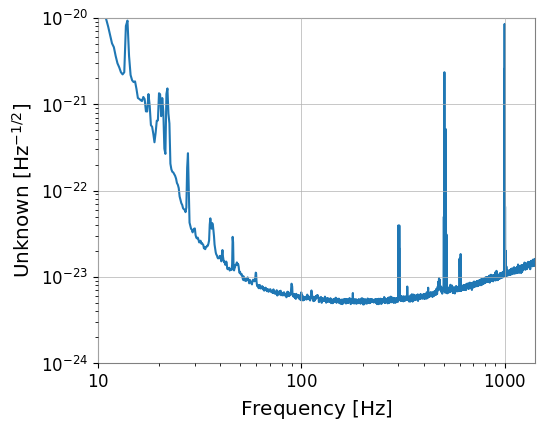

In [16]:
ldata2 = TimeSeries.fetch_open_data('H1', int(gps)-512, int(gps)+512, cache=True)
lasd2 = ldata2.asd(fftlength=4, method="median")
plot = lasd2.plot()
ax = plot.gca()
ax.set_xlim(10, 1400)
ax.set_ylim(1e-24, 1e-20)
plot.show(warn=False)

# Quiz Question 2 :

Cree una ASD (densidad espectral de amplitud) alrededor del momento de un evento de O1, GW150914, para el detector L1. Compare esto con las ASD alrededor de GW190412 para el detector L1. ¿Qué datos tienen menor ruido —y por lo tanto son más sensibles— alrededor de los 100 Hz?


In [17]:
from gwosc.datasets import event_gps
gps = event_gps('GW150914')
print(gps)

1126259462.4


In [18]:
segment = (int(gps)-5, int(gps)+5)
print(segment)

(1126259457, 1126259467)


In [19]:
from gwpy.timeseries import TimeSeries
ldata = TimeSeries.fetch_open_data('L1', *segment, verbose=True)
print(ldata)

Fetched 1 URLs from gwosc.org for [1126259457 .. 1126259467))
Reading data... [Done]
TimeSeries([-9.31087178e-19, -9.75697062e-19, -1.01074940e-18,
            ..., -1.13460681e-18, -1.11414494e-18,
            -1.15931435e-18]
           unit: dimensionless,
           t0: 1126259457.0 s,
           dt: 0.000244140625 s,
           name: Strain,
           channel: None)


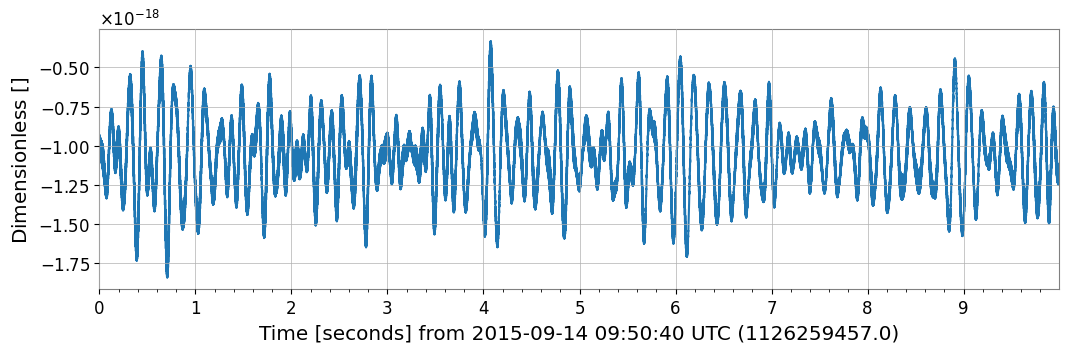

In [20]:
%matplotlib inline
plot = ldata.plot()

In [21]:
fft = ldata.fft()
print(fft)

FrequencySeries([-1.05219333e-18+0.00000000e+00j,
                 -9.36314427e-22+6.61514979e-23j,
                 -8.74693847e-22-3.26717194e-23j, ...,
                  6.63325463e-24-1.10870240e-26j,
                  6.73663868e-24-7.82178218e-26j,
                  6.69598891e-24+0.00000000e+00j]
                unit: dimensionless,
                f0: 0.0 Hz,
                df: 0.1 Hz,
                epoch: 1126259457.0,
                name: Strain,
                channel: None)


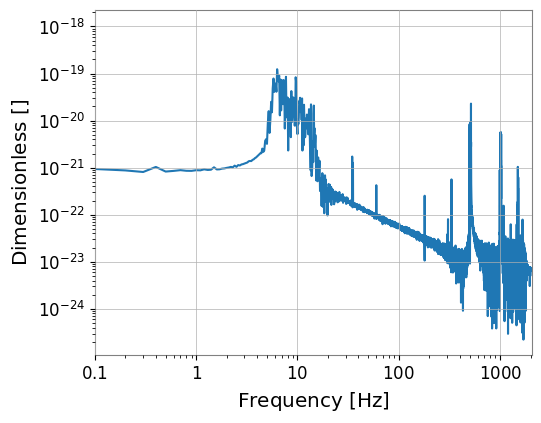

In [23]:
plot = fft.abs().plot(xscale="log", yscale="log")
plot.show(warn=False)

In [24]:
from scipy.signal import get_window
window = get_window('hann', ldata.size)
lwin = ldata * window

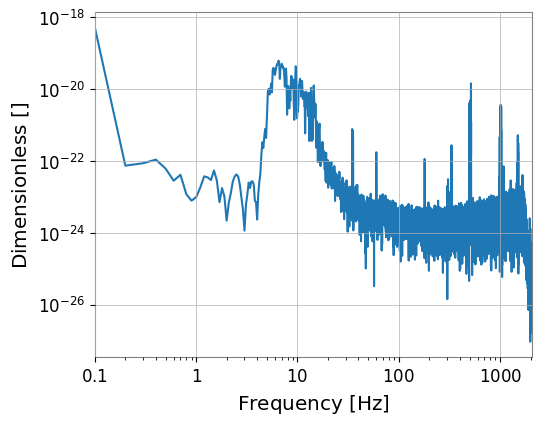

In [25]:
fftamp = lwin.fft().abs()
plot = fftamp.plot(xscale="log", yscale="log")
plot.show(warn=False)

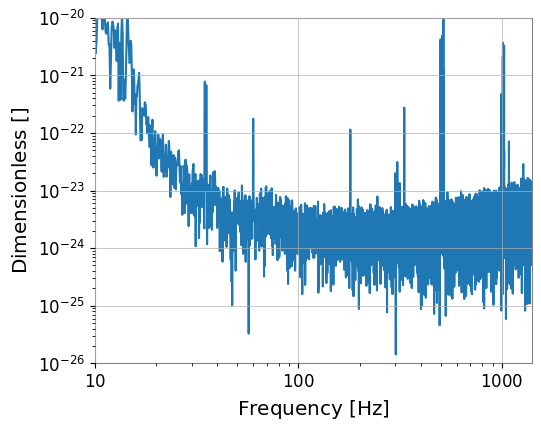

In [32]:
ax = plot.gca()
ax.set_xlim(10, 1400)
ax.set_ylim(1e-26, 1e-20)
plot

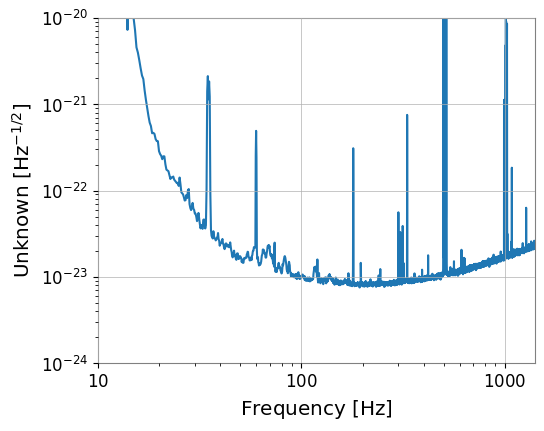

In [35]:
ldata2 = TimeSeries.fetch_open_data('L1', int(gps)-512, int(gps)+512, cache=True)
lasd2 = ldata2.asd(fftlength=4, method="median")
plot = lasd2.plot()
ax = plot.gca()
ax.set_xlim(10, 1400)
ax.set_ylim(1e-24, 1e-20)
plot.show(warn=False)